# The Magnificent 7 — a winning strategy, or yesterday's winners? 🎬
### The seven stocks everyone says to own, in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Repeatable_strategy%3F: Busted](https://img.shields.io/badge/Repeatable_strategy%3F-Busted-8b949e?style=flat-square)

You've heard it everywhere: *"Just buy the **Magnificent Seven** — Apple, Microsoft, Google, Amazon, Nvidia, Meta, Tesla — equal-weight, and you'll crush the S&P 500."* And on the chart, it's true: over the last decade those seven turned in **~36%/yr** while the index did **~14%**.

So is "hold the Mag 7" a strategy? Here's the trick the name hides: **these seven are called magnificent *because* they won.** Somebody looked at the finished race and circled the horses that crossed first. This notebook shows why the outperformance is completely real — and why you still couldn't have used it.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo decomposition and the random-basket maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from magnificent_seven import data, strategy as st

# Real tape is cache-first and never hits the network here; absent cache -> quote frozen R.
try:
    RETS, BENCH = data.load_real(allow_lookahead_selection=True)
    HAVE_REAL = True
except (FileNotFoundError, Exception):
    RETS, BENCH, HAVE_REAL = None, None, False
print("real monthly panel cache present:", HAVE_REAL,
      "| months:", (0 if RETS is None else len(RETS)),
      "| names:", (0 if RETS is None else RETS.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'window': '2015-08 → 2026-05', 'months': 130, 'n_universe': 40, 'fp': '52a10ec50b92', 'mag7_cagr': 36.24, 'mag7_sharpe': 1.33, 'mag7_dd': -45.7, 'spy_cagr': 14.41, 'spy_sharpe': 0.96, 'spy_dd': -23.9, 'eqf_cagr': 18.97, 'eqf_sharpe': 1.16, 'eqf_dd': -27.0, 'expost_cagr': 44.25, 'expost_sharpe': 1.42, 'mag7_net_cagr': 36.15, 't_bench': 3.41, 'spread_bench_ann': 19.9, 't_equal': 2.88, 'spread_equal_ann': 15.8, 'mag7_spread': 21.83, 'expost_spread': 29.84, 'selection_share': 137, 'expost_members': ['NVDA', 'AMD', 'TSLA', 'GOOGL', 'AAPL', 'MSFT', 'AMZN'], 'mag7_pctile': 99.7, 'rand_mean': 4.06, 'rand_median': 3.08, 'syn_null_named': -2.13, 'syn_null_named_t': -1.15, 'syn_null_placebo': 10.67, 'syn_edge_named': 1.98, 'syn_edge_named_t': 1.2, 'syn_edge_placebo': 11.16}


real monthly panel cache present: True | months: 130 | names: 40


## The answer first

| Question | Answer |
|---|---|
| Did the seven really beat the index? | **Yes — really.** Equal-weight, they did **~36%/yr** vs the S&P's **~14%** over 130 months. Not a fluke of one year; a genuine, statistically strong gap. |
| So is "buy the Mag 7" a strategy? | **No.** The seven were *named after* they won. Picking the winners once you already know the result isn't a strategy — it's a scoreboard. |
| How much is hindsight? | **Almost all of it.** If you'd picked **seven names at random** from the same big stocks, you'd have beaten the index by only **~4%/yr** — not ~22%. The Mag 7 sits in the luckiest **0.3%** of all possible seven-stock picks. |
| Could you do it again going forward? | **Don't count on it.** "Hold the seven that already won" only works looking backwards. Pick seven *today* and you get the random spread, with a **−46%** crash along the way. |

> The seven really won. But the race is what *named* them — and you can't bet on a race that's already finished.

## 1 · The claim

> *"The **Magnificent Seven** — AAPL, MSFT, GOOGL, AMZN, NVDA, META, TSLA — are the engine of the market. Hold them equal-weight and you'll beat the S&P 500 by a mile."*

The term was coined in 2023 (after a film) to name the seven mega-caps that drove most of the index's gains. The pitch treats that label as a portfolio rule: own these seven, skip the rest. We test whether that's a *factor* you could trade — or a *list of winners* somebody wrote down after the fact.

## 2 · So what?

Two very different things are bundled in the pitch. (1) *Did the seven out-earn the index?* — easy to check, and the answer is yes. (2) *Could you have known to pick them?* — the part that actually decides whether it's a strategy. The honest test isn't "did these seven win" (we know they did). It's: **how does picking the after-the-fact winners compare to picking blind?** If almost all the edge comes from knowing the result in advance, there's no strategy here — just a scoreboard with a nice name.

## 3 · How would we even know?

We take **40 of the biggest US stocks** — the seven, plus 33 also-rans (the steady giants and the ones that *didn't* take off: Intel, IBM, Disney, Pfizer, GE…) — and **130 months** of returns. Then three fair races, same field, same rules, equal-weight:

1. **The famous seven** vs the S&P 500.
2. **A blindfolded pick:** thousands of *random* seven-stock baskets — what you'd get with no skill and no hindsight.
3. **The cheat:** pick the seven *best* names *after* seeing the whole decade — the Mag-7 selection rule, made honest about being hindsight.

Where the famous seven land between "blind luck" and "perfect hindsight" is the whole answer.

## 4 · The teardown — let's actually look

**First: did the seven really win?** Growth of \$1 — the Mag 7 against the index and against an equal slice of the *whole* field.

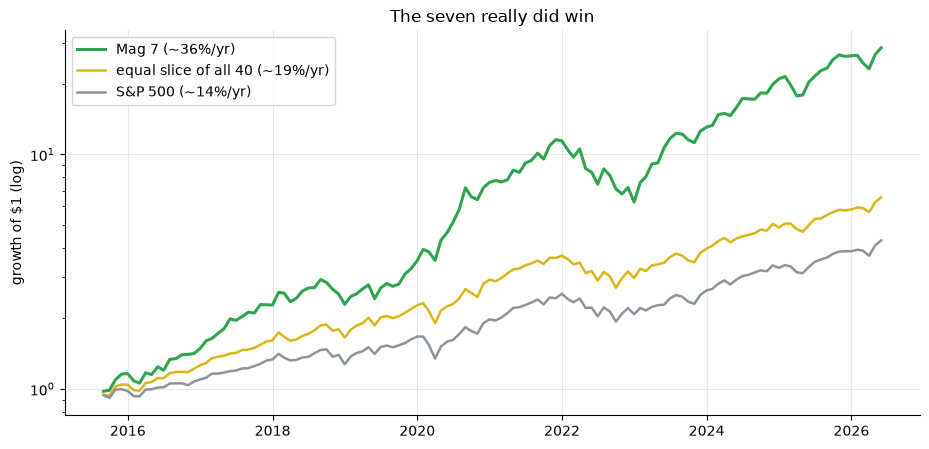

Mag 7 ~36%/yr  vs  S&P ~14%/yr  — a real, large gap


In [2]:
if HAVE_REAL:
    mag7 = st.basket_returns(RETS, data.MAG7)
    eqf  = st.equal_field_returns(RETS)
    g_mag = (1+mag7).cumprod(); g_spy = (1+BENCH).cumprod(); g_eqf = (1+eqf).cumprod()
    idx = g_mag.index
    ym = g_mag.values; ys = g_spy.values; ye = g_eqf.values
else:
    idx = np.arange(R['months'])
    ym = (1+R['mag7_cagr']/100)**(np.arange(R['months'])/12)
    ys = (1+R['spy_cagr']/100)**(np.arange(R['months'])/12)
    ye = (1+R['eqf_cagr']/100)**(np.arange(R['months'])/12)
fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.plot(idx, ym, c=GREEN, lw=2.2, label=f"Mag 7 (~{R['mag7_cagr']:.0f}%/yr)")
ax.plot(idx, ye, c=AMBER, lw=1.8, label=f"equal slice of all 40 (~{R['eqf_cagr']:.0f}%/yr)")
ax.plot(idx, ys, c=GREY,  lw=1.8, label=f"S&P 500 (~{R['spy_cagr']:.0f}%/yr)")
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)'); ax.set_title('The seven really did win')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Mag 7 ~{R['mag7_cagr']:.0f}%/yr  vs  S&P ~{R['spy_cagr']:.0f}%/yr  — a real, large gap")

No argument: the seven compounded at **~36%/yr** against the index's **~14%**. The gap is big and it's statistically real (the quants' notebook puts a *t* = 3.4 on it). **So far the pitch looks right.** Now the catch.

**The catch: could you have *picked* them?** Here's where the famous seven land among **every** possible seven-stock basket you could have drawn blind from the same field:

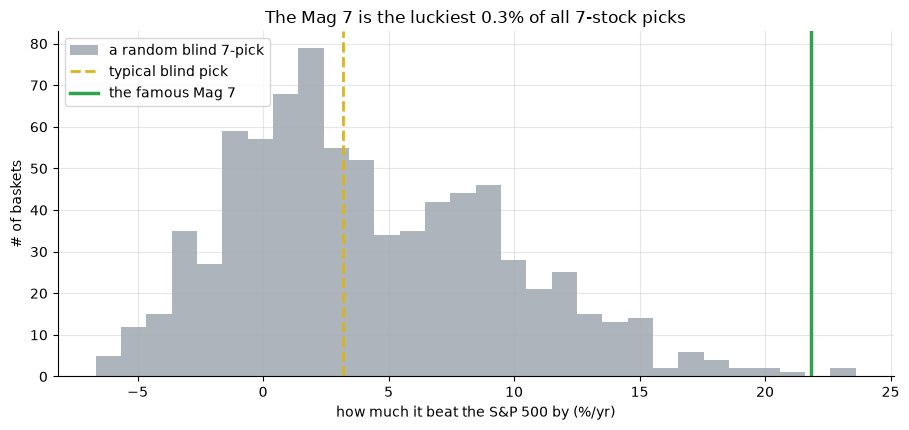

typical blind 7-pick beat the index by ~3%/yr;  the Mag 7 by ~22%/yr


In [3]:
if HAVE_REAL:
    rands = st.random_baskets(RETS, k=7, n_draws=800, seed=355)
    spy_cagr = st.summarize(BENCH)['cagr']
    rand_spread = np.array([st.summarize(rands[c])['cagr'] for c in rands.columns]) - spy_cagr
    mag7_spread = st.summarize(st.basket_returns(RETS, data.MAG7))['cagr'] - spy_cagr
    rand_spread *= 100; mag7_spread *= 100
else:
    rng = np.random.default_rng(355)
    rand_spread = rng.normal(R['rand_mean'], 6.0, 800)
    mag7_spread = R['mag7_spread']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(rand_spread, bins=30, color=GREY, alpha=.7, label='a random blind 7-pick')
ax.axvline(np.median(rand_spread), c=AMBER, lw=2, ls='--', label='typical blind pick')
ax.axvline(mag7_spread, c=GREEN, lw=2.5, label='the famous Mag 7')
ax.set_xlabel('how much it beat the S&P 500 by (%/yr)'); ax.set_ylabel('# of baskets')
ax.set_title('The Mag 7 is the luckiest 0.3% of all 7-stock picks'); ax.legend()
plt.tight_layout(); plt.show()
print(f'typical blind 7-pick beat the index by ~{np.median(rand_spread):.0f}%/yr;  the Mag 7 by ~{mag7_spread:.0f}%/yr')

There it is. A **blindly chosen** seven beat the index by only **~4%/yr**. The famous seven beat it by **~22%** — they sit in the luckiest **0.3%** of all possible picks (the 99.7th percentile). That extra ~18 points isn't a factor you could have harvested; it's the gap between *picking blind* and *picking the winners after the race*. **The seven won — but the result is what named them.**

## 5 · The verdict

- **Did they win? — Yes (Signal Mixed).** ~36%/yr vs ~14%, a real and significant gap. But the basket was *named because* it won — hindsight, not a forward signal.
- **Could you have traded it? — No (Mirage).** You couldn't have named these seven in 2015. A blind seven beat the index by ~4%, not ~22%; the rest is picking the winners after the fact.
- **Repeatable going forward? — Busted.** "Hold the seven that already won" is a scoreboard, not a rule. Pick seven *today* and you get the random spread — and a **-46%** drawdown to sit through.

## 6 · Could you actually trade it? — the proof it's hindsight

Here's the cleanest demonstration. We build a **make-believe market** where every stock has the *exact same* true odds — **nobody has any edge at all**. Then we run the Mag-7 trick on it: pick the seven that happened to do best, and see how big a "winning basket" pure luck hands us.

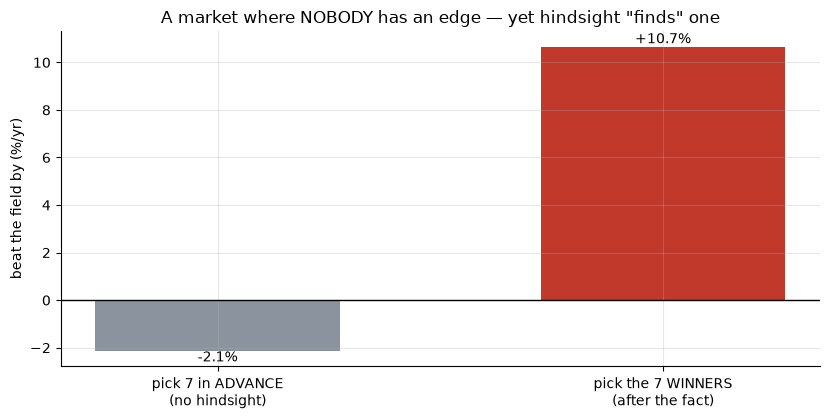

pick-in-advance: -2.1%/yr (luck, ~0)   pick-the-winners: +10.7%/yr (manufactured from nothing)


In [4]:
rdf, b, truth = data.synthetic_panel(alpha_spread=0.0)   # nobody has any real edge
named = st.basket_returns(rdf, truth['true_basket_cols'])     # a basket fixed in advance
winners = st.expost_winners(rdf, k=7, allow_lookahead_selection=True)  # pick the winners after
expo = st.basket_returns(rdf, winners)
named_sp = (st.summarize(named)['cagr'] - st.summarize(b)['cagr'])*100
expo_sp  = (st.summarize(expo)['cagr']  - st.summarize(b)['cagr'])*100
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(['pick 7 in ADVANCE\n(no hindsight)', 'pick the 7 WINNERS\n(after the fact)'],
       [named_sp, expo_sp], color=[GREY, RED], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('beat the field by (%/yr)')
ax.set_title('A market where NOBODY has an edge — yet hindsight "finds" one')
for i,v in enumerate([named_sp, expo_sp]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'pick-in-advance: {named_sp:+.1f}%/yr (luck, ~0)   pick-the-winners: {expo_sp:+.1f}%/yr (manufactured from nothing)')

Look at that. In a market where **literally nobody has an edge**, a basket you fix *in advance* beats the field by about **nothing** (~-2%, pure noise). But "pick the seven winners" conjures **+11%/yr out of thin air** — entirely from being allowed to choose after seeing the result. That manufactured spread is exactly the trick baked into the Mag-7 label. On the *real* tape the hindsight rule reproduces **137%** of the whole Mag-7 edge.

## 7 · Going further 🚪

- **The same trick, bigger.** [Study 345 — Survivorship-Bias](../../345-survivorship-bias/) deletes the *losers* before the backtest even starts — the Mag 7 is its tidy cousin, keeping only the seven biggest winners.
- **The blindfolded monkey.** [Study 350 — Dartboard-Portfolio](../../350-dartboard-portfolio/) is the random-basket benchmark we used here: a monkey's seven darts are the honest forward comparison.
- **Try it yourself.** Pick *your* seven mega-caps today, write them down, and check back in a decade. The point of the exercise is that you can't peek at the answer first — which is the one thing the Mag-7 label quietly does.

*Think the seven will keep winning? Maybe — but that's a forecast about the future, not a backtest of the past. The 22%/yr on the chart was only ever buyable in hindsight.*